In [80]:
import pandas as pd

In [81]:
kaggle = pd.read_csv('data/final_kaggle_dataset.csv',escapechar='\\')

In [82]:
kaggle

,song,artists,lyrics,genres
0,Illusions,['Cypress Hill'],Some people tell me that I need help Some peop...,"['chicano rap', 'gangster rap', 'hardcore hip ..."
1,Touching the Ground,['Brandi Carlile'],I swear when we touched I saw heaven in your ...,"['folk', 'indie pop', 'lilith', 'neo mellow', ..."
2,Nothing Is Stopping You,['Big Sean'],Nothing is stopping you Stopping you Stopping ...,"['detroit hip hop', 'hip hop', 'pop', 'pop rap..."
3,I Shall Believe,['Sheryl Crow'],Come to me now And lay your hands over me Even...,"['lilith', 'mellow gold', 'neo mellow', 'new w..."
4,Why Trust You,['Alice Cooper'],You come on strong with a great big smile But ...,"['album rock', 'blues rock', 'classic rock', '..."
...,...,...,...,...
5744,New Morning,['My Morning Jacket'],Wakin' up feelin' good and limber When the tel...,"['alternative rock', 'blues rock', 'indie folk..."
5745,Bel Air,['Lana Del Rey'],Gargoyles standing at the front of your gate T...,"['art pop', 'pop']"
5746,Harambe,['Young Thug'],Mafia Billboard Hitmakers Yeah AP gang bitch...,"['atl hip hop', 'gangster rap', 'hip hop', 'me..."
5747,Fun,['Selena Gomez'],This is just what the doctor ordered Put a gol...,"['dance pop', 'pop', 'post-teen pop']"


In [83]:
api = pd.read_csv('data/additional_songs.csv',escapechar='\\')

In [84]:
api

,song,artists,genres,lyrics
0,Ollaanko tämä kesä näin?,['Olavi Uusivirta'],rock,[Säkeistö 1]\nKesä on täällä taas\nIstutaan hi...
1,Levoton Tuhkimo,['Dingo'],rock,[Säkeistö 1]\nJuot ja katselet vieraisiin pöyt...
2,Matkustaja,['Egotrippi'],rock,"[Säkeistö 1]\nYöllä linja-autossa, yksi väsyny..."
3,In the End,['Linkin Park'],rock,[Intro: Chester Bennington]\nIt starts with on...
4,Todella kaunis,['Zen Cafe'],rock,[Säkeistö 1]\nMe kohtaisimme aina silloin kun ...
...,...,...,...,...
768,Headstone Lane,['UDM'],trance,Hands up now {*repeat 14X*}\n\n[Hook: Nelly]\n...
769,Wish You Were Here,['JES'],trance,"So, so you think you can tell Heaven from Hell..."
770,See the Sun,['ASP Project'],trance,See the sun as it sets behind the light\nAnd I...
771,Risk It All,['Altitude'],trance,They said\nSay a prayer for the sinners\nSay a...


In [85]:
api.isna().sum()

song       0
artists    0
genres     0
lyrics     0
dtype: int64

In [86]:
api[api['lyrics']=="THIS SONG DON'T HAVE A LIRICS"]

,song,artists,genres,lyrics
772,No Hands But Yours,['Mandala'],trance,THIS SONG DON'T HAVE A LIRICS


In [87]:
api = api[api['lyrics']!="THIS SONG DON'T HAVE A LIRICS"]

In [88]:
from langdetect import detect

In [89]:
def detect_lang(x):
    try:
        return detect(str(x))
    except:
        return 'unknown'

In [90]:
languages = api['lyrics'].apply(detect_lang)

<Axes: xlabel='lyrics'>

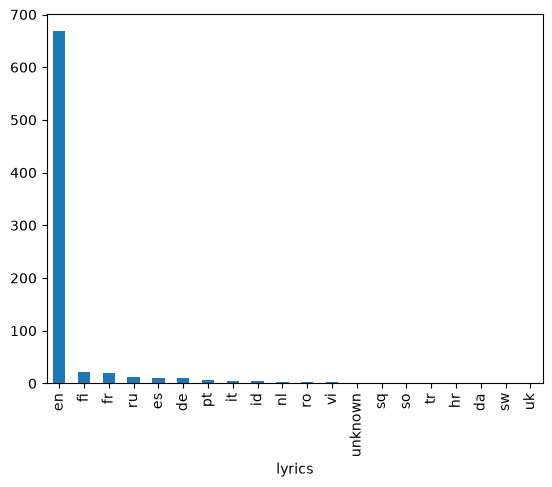

In [91]:
languages.value_counts().plot(kind='bar')

In [92]:
api.shape

(772, 4)

In [93]:
api = api[languages=='en']

In [94]:
api.shape

(668, 4)

In [95]:
api['genres'] = api['genres'].apply(lambda x: [x])

In [96]:
api

,song,artists,genres,lyrics
3,In the End,['Linkin Park'],[rock],[Intro: Chester Bennington]\nIt starts with on...
8,Enter Sandman - Remastered 2021,['Metallica'],[rock],BTS - Butter\nMaroon 5 - Memories\nImagine Dra...
9,Numb,['Linkin Park'],[rock],[Verse 1: Chester Bennington]\nI'm tired of be...
11,Kahedi Radio Interlude 3,['Max Herre'],[rap],Annotation typeJanvier :\n* 04/01 : La Ligne B...
13,Forgot about Father (Say Miss),['Natalac'],[rap],"The mother was small and thin, with shoulders,..."
...,...,...,...,...
767,BASH!!,"['Marco V', 'Jochen Miller']",[dutch trance],God broke the mould\nWhen he made this one I k...
768,Headstone Lane,['UDM'],[trance],Hands up now {*repeat 14X*}\n\n[Hook: Nelly]\n...
769,Wish You Were Here,['JES'],[trance],"So, so you think you can tell Heaven from Hell..."
770,See the Sun,['ASP Project'],[trance],See the sun as it sets behind the light\nAnd I...


# Объединение двух датасетов

In [97]:
concated = pd.concat([kaggle,api],axis=0)
concated

,song,artists,lyrics,genres
0,Illusions,['Cypress Hill'],Some people tell me that I need help Some peop...,"['chicano rap', 'gangster rap', 'hardcore hip ..."
1,Touching the Ground,['Brandi Carlile'],I swear when we touched I saw heaven in your ...,"['folk', 'indie pop', 'lilith', 'neo mellow', ..."
2,Nothing Is Stopping You,['Big Sean'],Nothing is stopping you Stopping you Stopping ...,"['detroit hip hop', 'hip hop', 'pop', 'pop rap..."
3,I Shall Believe,['Sheryl Crow'],Come to me now And lay your hands over me Even...,"['lilith', 'mellow gold', 'neo mellow', 'new w..."
4,Why Trust You,['Alice Cooper'],You come on strong with a great big smile But ...,"['album rock', 'blues rock', 'classic rock', '..."
...,...,...,...,...
767,BASH!!,"['Marco V', 'Jochen Miller']",God broke the mould\nWhen he made this one I k...,[dutch trance]
768,Headstone Lane,['UDM'],Hands up now {*repeat 14X*}\n\n[Hook: Nelly]\n...,[trance]
769,Wish You Were Here,['JES'],"So, so you think you can tell Heaven from Hell...",[trance]
770,See the Sun,['ASP Project'],See the sun as it sets behind the light\nAnd I...,[trance]


In [98]:
concated[['song','artists']].duplicated().sum()

np.int64(188)

In [99]:
concated[concated[['song','artists']].duplicated(keep=False)].sort_values('song')

,song,artists,lyrics,genres
253,A Horse with No Name,"['America', 'George Martin']",[Verse 1]\nOn the first part of the journey\nI...,[folk]
312,A Horse with No Name,"['America', 'George Martin']",[Verse 1]\nOn the first part of the journey\nI...,[folk rock]
104,A Whiter Shade of Pale,['The Everly Brothers'],We tripped the light Fandango\nAnd turned cart...,[mellow gold]
493,A Whiter Shade of Pale,['The Everly Brothers'],We tripped the light Fandango\nAnd turned cart...,[adult standards]
1516,Anything,['JAY-Z'],Uh huh yea yeah Duro!You gotta let it bump Uh...,"['east coast hip hop', 'hip hop', 'rap']"
...,...,...,...,...
4024,Where Is Here Now,['Hardwell'],I awaken on a sidewalk On a street alone City...,"['dance pop', 'edm', 'electro house', 'pop dan..."
2180,Wind Up,['Major Lazer'],Major Lazer is blasting Major Lazer is blastin...,"['dance pop', 'edm', 'electro house', 'pop', '..."
3534,Wind Up,['Major Lazer'],Major Lazer is blasting Major Lazer is blastin...,"['dance pop', 'edm', 'electro house', 'pop', '..."
4545,Your Song,['Elton John'],It's a little bit funny this feeling inside I...,"['glam rock', 'mellow gold', 'piano rock']"


In [100]:
concated = concated.drop_duplicates(subset=['song','artists'])

In [101]:
concated

,song,artists,lyrics,genres
0,Illusions,['Cypress Hill'],Some people tell me that I need help Some peop...,"['chicano rap', 'gangster rap', 'hardcore hip ..."
1,Touching the Ground,['Brandi Carlile'],I swear when we touched I saw heaven in your ...,"['folk', 'indie pop', 'lilith', 'neo mellow', ..."
2,Nothing Is Stopping You,['Big Sean'],Nothing is stopping you Stopping you Stopping ...,"['detroit hip hop', 'hip hop', 'pop', 'pop rap..."
3,I Shall Believe,['Sheryl Crow'],Come to me now And lay your hands over me Even...,"['lilith', 'mellow gold', 'neo mellow', 'new w..."
4,Why Trust You,['Alice Cooper'],You come on strong with a great big smile But ...,"['album rock', 'blues rock', 'classic rock', '..."
...,...,...,...,...
767,BASH!!,"['Marco V', 'Jochen Miller']",God broke the mould\nWhen he made this one I k...,[dutch trance]
768,Headstone Lane,['UDM'],Hands up now {*repeat 14X*}\n\n[Hook: Nelly]\n...,[trance]
769,Wish You Were Here,['JES'],"So, so you think you can tell Heaven from Hell...",[trance]
770,See the Sun,['ASP Project'],See the sun as it sets behind the light\nAnd I...,[trance]


In [102]:
import csv

In [103]:
concated.to_csv('data/final_dataset.csv',index=False,encoding='utf-8',escapechar="\\",quoting=csv.QUOTE_MINIMAL)